In [25]:
from neuralprophet import NeuralProphet
NeuralProphet()

In [26]:
import sys
import os

# Ajouter la racine du projet au PYTHONPATH
sys.path.append(os.path.abspath("../.."))

import pandas as pd
from src.prediction.time_series import train_prophet, forecast_prophet


# Charger le dataset d'exemple
df = pd.read_csv("../../data/examples/urgences_exemple.csv")

# Convertir la colonne datetime
df["datetime"] = pd.to_datetime(df["datetime"])

# Vérifier la structure
df.head()

,datetime,arrivals
0,2024-01-01 00:00:00,16.0
1,2024-01-01 01:00:00,15.0
2,2024-01-01 02:00:00,16.0
3,2024-01-01 03:00:00,18.0
4,2024-01-01 04:00:00,15.0


In [27]:
import pandas as pd
from neuralprophet import NeuralProphet

def train_prophet(df: pd.DataFrame, date_col: str, target_col: str):
    model_df = df[[date_col, target_col]].rename(columns={date_col: "ds", target_col: "y"})
    model = NeuralProphet()
    model.fit(model_df, freq="H")
    return model

def train_prophet(df, date_col, target_col):
    model_df = df[[date_col, target_col]].rename(columns={date_col: "ds", target_col: "y"})
    model = NeuralProphet()
    model.fit(model_df, freq="H")
    return model, model_df

def forecast_prophet(model, df, periods: int, freq: str = "H"):
    future = model.make_future_dataframe(
        df=df,
        periods=periods,
        n_historic_predictions=True
    )
    forecast = model.predict(future)
    return forecast


In [28]:
import inspect
print(inspect.signature(forecast_prophet))



(model, df, periods: int, freq: str = 'H')


WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:464: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  if df.groupby("ID").apply(lambda x: x.duplicated("ds").any()).any():

WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (N

Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (34) is too small than the required number                     for the learning rate finder (233). The results might not be optimal.


Finding best initial lr:   0%|          | 0/233 [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency h corresponds to 99.954% of the data.
WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:1173: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  aux_ts = pd.DataFrame(pd.date_range("1994-01-01", periods=100, freq=freq_str))

WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype

Predicting: |          | 0/? [00:00<?, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


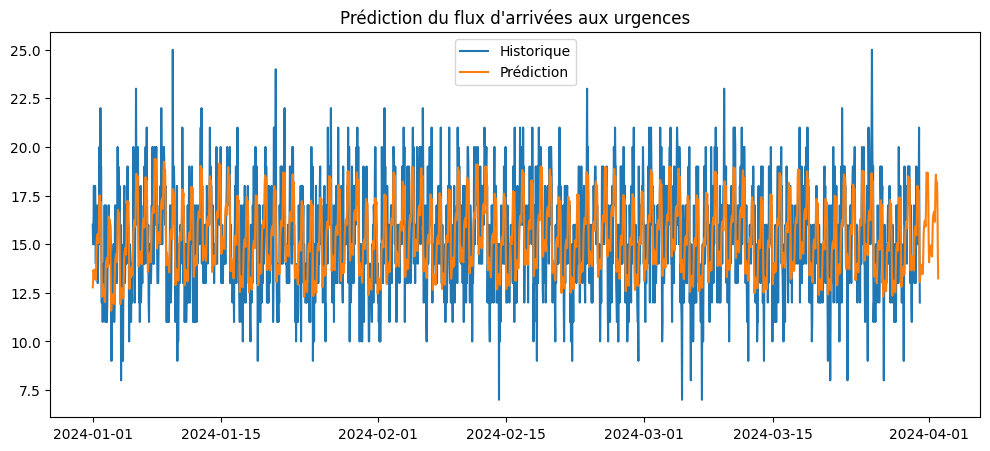

In [29]:
import matplotlib.pyplot as plt

model, model_df = train_prophet(df, "datetime", "arrivals")
forecast = forecast_prophet(model=model, df=model_df, periods=48)
#forecast.head()
#forecast.columns

plt.figure(figsize=(12, 5))
plt.plot(df["datetime"], df["arrivals"], label="Historique")
plt.plot(forecast["ds"], forecast["yhat1"], label="Prédiction")
plt.legend()
plt.title("Prédiction du flux d'arrivées aux urgences")
plt.show()


In [30]:
import numpy as np
import pandas as pd

mu = 20.0  # ajuster selon la réalité

# On part de ton forecast existant
mm1 = forecast.copy()
mm1["lambda"] = mm1["yhat1"]          # arrivées prédites par heure
mm1["rho"] = mm1["lambda"] / mu       # taux d'occupation

# On force la stabilité : on ignore (ou marque) les heures où lambda >= mu
mm1["stable"] = mm1["lambda"] < mu

# Formules M/M/1 (là où c'est stable)
mm1.loc[mm1["stable"], "Lq"] = (mm1["rho"]**2 / (1 - mm1["rho"]))[mm1["stable"]]
mm1.loc[mm1["stable"], "L"]  = (mm1["rho"] / (1 - mm1["rho"]))[mm1["stable"]]
mm1.loc[mm1["stable"], "Wq"] = mm1["Lq"][mm1["stable"]] / mm1["lambda"][mm1["stable"]]
mm1.loc[mm1["stable"], "W"]  = mm1["L"][mm1["stable"]]  / mm1["lambda"][mm1["stable"]]

In [31]:
mm1["stable"].value_counts()

stable
True    2209
Name: count, dtype: int64

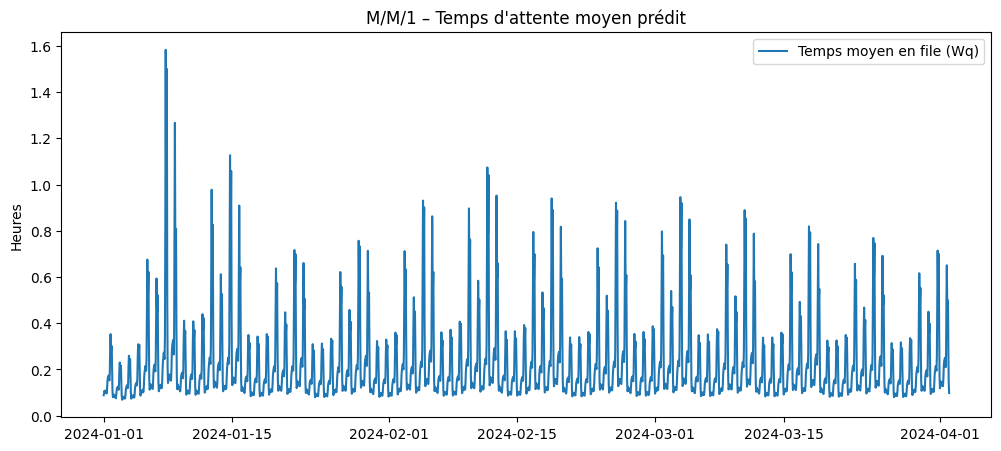

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(mm1["ds"], mm1["Wq"], label="Temps moyen en file (Wq)")
plt.ylabel("Heures")
plt.legend()
plt.title("M/M/1 – Temps d'attente moyen prédit")
plt.show()

In [33]:
import numpy as np
import pandas as pd

mu_doc = 3.3  # patients/heure par médecin (estimé)
c_values = [3, 4, 5, 6, 7]  # scénarios de nombre de médecins

lambda_t = forecast["yhat1"].values  # arrivées prédites par heure
ds = forecast["ds"].values

def mmc_metrics(lmbda, mu_doc, c):
    mu_tot = c * mu_doc
    rho = lmbda / mu_tot  # taux d'occupation global

    if lmbda == 0:
        return rho, 0.0  # pas d'arrivées, pas d'attente

    a = lmbda / mu_doc  # charge offerte

    # Calcul de P0 (probabilité que le système soit vide)
    sum_terms = sum((a**k) / np.math.factorial(k) for k in range(c))
    last_term = (a**c) / (np.math.factorial(c) * (1 - rho)) if rho < 1 else np.inf

    if rho >= 1:
        return rho, np.inf  # système instable

    P0 = 1.0 / (sum_terms + last_term)

    # Probabilité qu'un patient attende (Erlang C)
    Pc = (a**c / (np.math.factorial(c) * (1 - rho))) * P0

    # Temps moyen en file (Wq)
    Wq = Pc / (c * mu_doc - lmbda)  # en heures

    return rho, Wq

# On construit un DataFrame avec un Wq par scénario de c
mmc = pd.DataFrame({"ds": ds, "lambda": lambda_t})

for c in c_values:
    rhos = []
    wqs = []
    for lmbda in lambda_t:
        rho, Wq = mmc_metrics(lmbda, mu_doc, c)
        rhos.append(rho)
        wqs.append(Wq)
    mmc[f"rho_c{c}"] = rhos
    mmc[f"Wq_c{c}"] = wqs


WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_30360\3328086401.py:20: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  sum_terms = sum((a**k) / np.math.factorial(k) for k in range(c))



WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_30360\3328086401.py:20: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  sum_terms = sum((a**k) / np.math.factorial(k) for k in range(c))

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_30360\3328086401.py:21: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  last_term = (a**c) / (np.math.factorial(c) * (1 - rho)) if rho < 1 else np.inf

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_30360\3328086401.py:29: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  Pc = (a**c / (np.math.factorial(c) * (1 - rho))) * P0

WARN

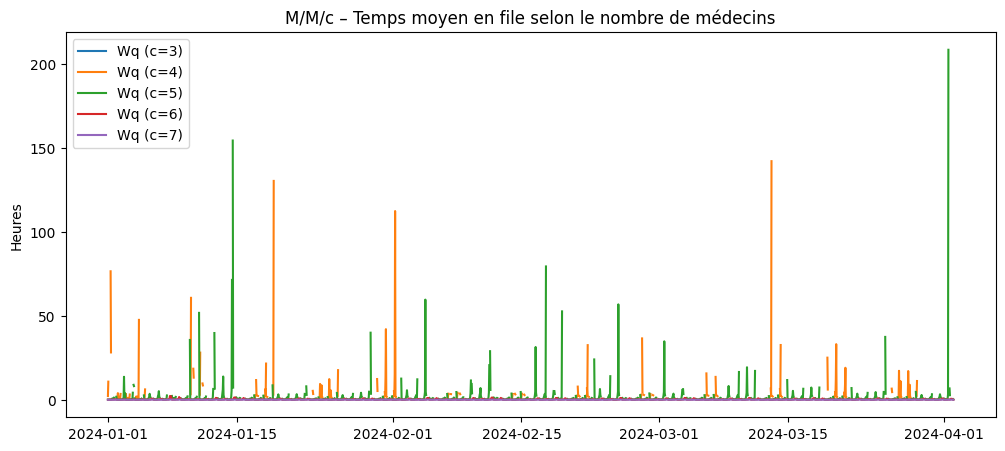

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
for c in c_values:
    plt.plot(mmc["ds"], mmc[f"Wq_c{c}"], label=f"Wq (c={c})")
plt.ylabel("Heures")
plt.title("M/M/c – Temps moyen en file selon le nombre de médecins")
plt.legend()
plt.show()

In [35]:
Wq_target = 0.5  # 30 minutes

results = []

for c in c_values:
    Wq = mmc[f"Wq_c{c}"]
    # proportion d'heures où le temps d'attente est sous le seuil
    pct_ok = (Wq < Wq_target).mean() * 100
    results.append((c, pct_ok))

results


[(3, 0.0),
 (4, 0.04526935264825713),
 (5, 45.81258488003622),
 (6, 91.98732458125849),
 (7, 100.0)]

In [36]:
optimal = None
for c, pct in results:
    if pct >= 95:   # objectif : 95% des heures sous 30 minutes
        optimal = c
        break

optimal

7

In [37]:
import pandas as pd

df_results = pd.DataFrame(results, columns=["Médecins (c)", "% heures Wq < 30 min"])
df_results

,Médecins (c),% heures Wq < 30 min
0,3,0.000000
1,4,0.045269
2,5,45.812585
3,6,91.987325
4,7,100.000000


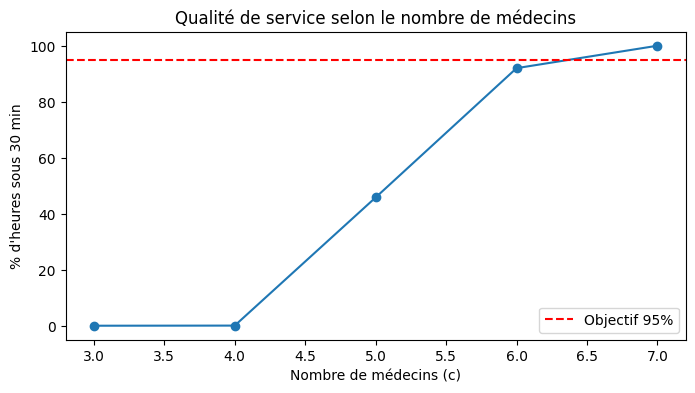

In [38]:
plt.figure(figsize=(8,4))
plt.plot(df_results["Médecins (c)"], df_results["% heures Wq < 30 min"], marker="o")
plt.axhline(95, color="red", linestyle="--", label="Objectif 95%")
plt.ylabel("% d'heures sous 30 min")
plt.xlabel("Nombre de médecins (c)")
plt.title("Qualité de service selon le nombre de médecins")
plt.legend()
plt.show()

In [39]:
Wq_target = 0.25  # 15 minutes

results_15 = []

for c in c_values:
    Wq = mmc[f"Wq_c{c}"]
    pct_ok = (Wq < Wq_target).mean() * 100
    results_15.append((c, pct_ok))

results_15

[(3, 0.0),
 (4, 0.0),
 (5, 26.346763241285647),
 (6, 81.25848800362154),
 (7, 100.0)]

In [40]:
optimal_15 = None
for c, pct in results_15:
    if pct >= 95:   # objectif : 95% des heures sous 15 minutes
        optimal_15 = c
        break

optimal_15


7

In [41]:
def optimal_c_per_hour(lambda_t, mu_doc, Wq_target=0.5, c_max=12):
    for c in range(1, c_max+1):
        rho, Wq = mmc_metrics(lambda_t, mu_doc, c)
        if Wq < Wq_target:
            return c
    return c_max  # si jamais aucun c ne suffit

mmc["c_opt_30min"] = [
    optimal_c_per_hour(lmbda, mu_doc, Wq_target=0.5)
    for lmbda in mmc["lambda"]
]

mmc["c_opt_15min"] = [
    optimal_c_per_hour(lmbda, mu_doc, Wq_target=0.25)
    for lmbda in mmc["lambda"]
]

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_30360\3328086401.py:20: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  sum_terms = sum((a**k) / np.math.factorial(k) for k in range(c))

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_30360\3328086401.py:21: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  last_term = (a**c) / (np.math.factorial(c) * (1 - rho)) if rho < 1 else np.inf

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_30360\3328086401.py:29: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  Pc = (a**c / (np.math.factorial(c) * (1 - rho))) * P0

WARN

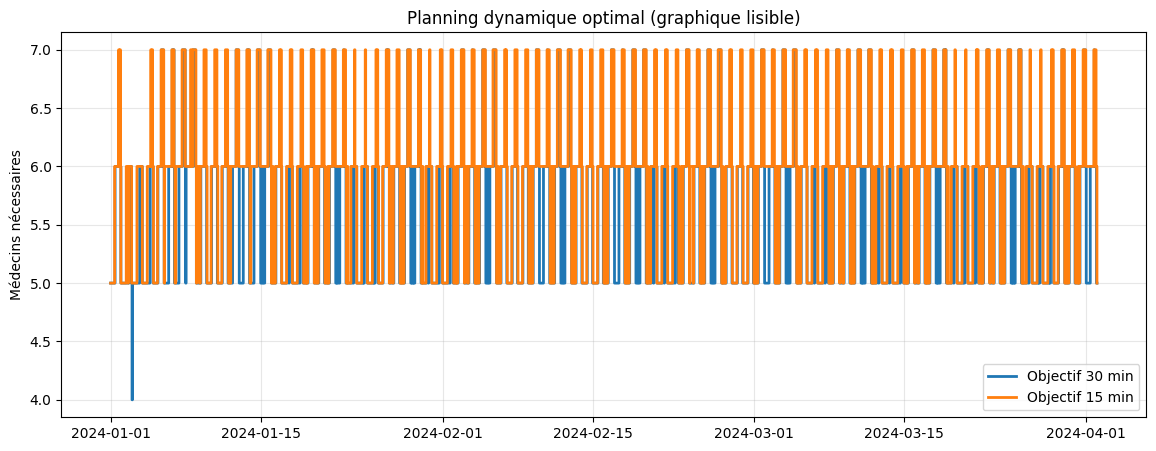

In [42]:
#plt.figure(figsize=(12,5))
#plt.plot(mmc["ds"], mmc["c_opt_30min"], label="Objectif 30 min")
#plt.plot(mmc["ds"], mmc["c_opt_15min"], label="Objectif 15 min")
#plt.ylabel("Médecins nécessaires")
#plt.title("Planning dynamique optimal")
#plt.legend()
#plt.show()

plt.figure(figsize=(14, 5))

plt.step(mmc["ds"], mmc["c_opt_30min"], where="post", label="Objectif 30 min", linewidth=2)
plt.step(mmc["ds"], mmc["c_opt_15min"], where="post", label="Objectif 15 min", linewidth=2)

plt.ylabel("Médecins nécessaires")
plt.title("Planning dynamique optimal (graphique lisible)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [43]:
import pandas as pd

def compress_schedule(times, values):
    """
    Regroupe les périodes consécutives où la valeur reste identique.
    """
    segments = []
    start = times[0]
    current_value = values[0]

    for i in range(1, len(times)):
        if values[i] != current_value:
            segments.append((start, times[i-1], current_value))
            start = times[i]
            current_value = values[i]

    # dernier segment
    segments.append((start, times.iloc[-1], current_value))
    return segments

# Création des segments pour les deux objectifs
segments_30 = compress_schedule(mmc["ds"], mmc["c_opt_30min"])
segments_15 = compress_schedule(mmc["ds"], mmc["c_opt_15min"])

# Fusion des deux plannings
rows = []
for (s30, e30, v30), (_, _, v15) in zip(segments_30, segments_15):
    rows.append({
        "Début": s30,
        "Fin": e30,
        "Médecins (30 min)": v30,
        "Médecins (15 min)": v15
    })

planning_df = pd.DataFrame(rows)
planning_df


,Début,Fin,Médecins (30 min),Médecins (15 min)
0,2024-01-01 00:00:00,2024-01-01 09:00:00,5,5
1,2024-01-01 10:00:00,2024-01-01 22:00:00,6,6
2,2024-01-01 23:00:00,2024-01-02 16:00:00,5,7
3,2024-01-02 17:00:00,2024-01-02 22:00:00,6,6
4,2024-01-02 23:00:00,2024-01-02 23:00:00,5,7
...,...,...,...,...
380,2024-04-01 00:00:00,2024-04-01 08:00:00,5,7
381,2024-04-01 09:00:00,2024-04-01 17:00:00,6,6
382,2024-04-01 18:00:00,2024-04-01 18:00:00,7,5
383,2024-04-01 19:00:00,2024-04-01 22:00:00,6,6


In [44]:
# Résumé par jour
daily_summary = mmc.groupby(mmc["ds"].dt.date).agg({
    "c_opt_30min": "max",
    "c_opt_15min": "max"
}).reset_index()

daily_summary.columns = ["Date", "Médecins (30 min)", "Médecins (15 min)"]
daily_summary

,Date,Médecins (30 min),Médecins (15 min)
0,2024-01-01,6,7
1,2024-01-02,6,6
2,2024-01-03,6,6
3,2024-01-04,6,7
4,2024-01-05,7,7
...,...,...,...
88,2024-03-29,7,7
89,2024-03-30,6,7
90,2024-03-31,7,7
91,2024-04-01,7,7


In [45]:
mmc["week"] = mmc["ds"].dt.isocalendar().week

weekly_summary = mmc.groupby("week").agg({
    "c_opt_30min": "max",
    "c_opt_15min": "max"
}).reset_index()

weekly_summary.columns = ["Semaine", "Médecins (30 min)", "Médecins (15 min)"]
weekly_summary


,Semaine,Médecins (30 min),Médecins (15 min)
0,1,7,7
1,2,7,7
2,3,7,7
3,4,7,7
4,5,7,7
5,6,7,7
6,7,7,7
7,8,7,7
8,9,7,7
9,10,7,7


In [46]:
def zone_color(c):
    if c <= 5:
        return "🟢 Creuse"
    elif c == 6:
        return "🟡 Normale"
    else:
        return "🔴 Pointe"

daily_summary["Zone (30 min)"] = daily_summary["Médecins (30 min)"].apply(zone_color)
daily_summary["Zone (15 min)"] = daily_summary["Médecins (15 min)"].apply(zone_color)

daily_summary


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min)
0,2024-01-01,6,7,🟡 Normale,🔴 Pointe
1,2024-01-02,6,6,🟡 Normale,🟡 Normale
2,2024-01-03,6,6,🟡 Normale,🟡 Normale
3,2024-01-04,6,7,🟡 Normale,🔴 Pointe
4,2024-01-05,7,7,🔴 Pointe,🔴 Pointe
...,...,...,...,...,...
88,2024-03-29,7,7,🔴 Pointe,🔴 Pointe
89,2024-03-30,6,7,🟡 Normale,🔴 Pointe
90,2024-03-31,7,7,🔴 Pointe,🔴 Pointe
91,2024-04-01,7,7,🔴 Pointe,🔴 Pointe


In [47]:
cost_doc = 80
cost_wait = 20

def total_cost(lmbda, mu_doc, c):
    rho, Wq = mmc_metrics(lmbda, mu_doc, c)
    return c * cost_doc + lmbda * Wq * cost_wait

mmc["cost_30min"] = [
    total_cost(lmbda, mu_doc, c)
    for lmbda, c in zip(mmc["lambda"], mmc["c_opt_30min"])
]

mmc["cost_15min"] = [
    total_cost(lmbda, mu_doc, c)
    for lmbda, c in zip(mmc["lambda"], mmc["c_opt_15min"])
]

daily_cost = mmc.groupby(mmc["ds"].dt.date).agg({
    "cost_30min": "sum",
    "cost_15min": "sum"
}).reset_index()

daily_cost.columns = ["Date", "Coût total (30 min)", "Coût total (15 min)"]
daily_cost


WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_30360\3328086401.py:20: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  sum_terms = sum((a**k) / np.math.factorial(k) for k in range(c))

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_30360\3328086401.py:21: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  last_term = (a**c) / (np.math.factorial(c) * (1 - rho)) if rho < 1 else np.inf

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_30360\3328086401.py:29: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  Pc = (a**c / (np.math.factorial(c) * (1 - rho))) * P0

WARN

,Date,Coût total (30 min),Coût total (15 min)
0,2024-01-01,11928.416086,11960.067834
1,2024-01-02,11263.337750,11320.143541
2,2024-01-03,11368.668141,11375.318377
3,2024-01-04,11651.481572,11663.960272
4,2024-01-05,12382.724641,12329.309598
...,...,...,...
88,2024-03-29,12461.164068,12316.509417
89,2024-03-30,12472.226844,12435.265802
90,2024-03-31,12467.045322,12421.535972
91,2024-04-01,13175.463676,12834.901477


In [48]:
daily_cost = mmc.groupby(mmc["ds"].dt.date).agg({
    "cost_30min": "sum",
    "cost_15min": "sum"
}).reset_index()

daily_cost.columns = ["Date", "Coût total (30 min)", "Coût total (15 min)"]
daily_cost


,Date,Coût total (30 min),Coût total (15 min)
0,2024-01-01,11928.416086,11960.067834
1,2024-01-02,11263.337750,11320.143541
2,2024-01-03,11368.668141,11375.318377
3,2024-01-04,11651.481572,11663.960272
4,2024-01-05,12382.724641,12329.309598
...,...,...,...
88,2024-03-29,12461.164068,12316.509417
89,2024-03-30,12472.226844,12435.265802
90,2024-03-31,12467.045322,12421.535972
91,2024-04-01,13175.463676,12834.901477


In [49]:
# Résumé par jour
daily_summary = mmc.groupby(mmc["ds"].dt.date).agg({
    "c_opt_30min": "max",
    "c_opt_15min": "max"
}).reset_index()

daily_summary.columns = ["Date", "Médecins (30 min)", "Médecins (15 min)"]
daily_summary


,Date,Médecins (30 min),Médecins (15 min)
0,2024-01-01,6,7
1,2024-01-02,6,6
2,2024-01-03,6,6
3,2024-01-04,6,7
4,2024-01-05,7,7
...,...,...,...
88,2024-03-29,7,7
89,2024-03-30,6,7
90,2024-03-31,7,7
91,2024-04-01,7,7


In [50]:
mmc["week"] = mmc["ds"].dt.isocalendar().week

weekly_summary = mmc.groupby("week").agg({
    "c_opt_30min": "max",
    "c_opt_15min": "max"
}).reset_index()

weekly_summary.columns = ["Semaine", "Médecins (30 min)", "Médecins (15 min)"]
weekly_summary


,Semaine,Médecins (30 min),Médecins (15 min)
0,1,7,7
1,2,7,7
2,3,7,7
3,4,7,7
4,5,7,7
5,6,7,7
6,7,7,7
7,8,7,7
8,9,7,7
9,10,7,7


In [51]:
def zone_color(c):
    if c <= 5:
        return "🟢 Creuse"
    elif c == 6:
        return "🟡 Normale"
    else:
        return "🔴 Pointe"

daily_summary["Zone (30 min)"] = daily_summary["Médecins (30 min)"].apply(zone_color)
daily_summary["Zone (15 min)"] = daily_summary["Médecins (15 min)"].apply(zone_color)


In [52]:
cost_doc = 80
cost_wait = 20

def total_cost(lmbda, mu_doc, c):
    rho, Wq = mmc_metrics(lmbda, mu_doc, c)
    return c * cost_doc + lmbda * Wq * cost_wait

mmc["cost_30min"] = [
    total_cost(lmbda, mu_doc, c)
    for lmbda, c in zip(mmc["lambda"], mmc["c_opt_30min"])
]

mmc["cost_15min"] = [
    total_cost(lmbda, mu_doc, c)
    for lmbda, c in zip(mmc["lambda"], mmc["c_opt_15min"])
]

daily_cost = mmc.groupby(mmc["ds"].dt.date).agg({
    "cost_30min": "sum",
    "cost_15min": "sum"
}).reset_index()

daily_cost.columns = ["Date", "Coût total (30 min)", "Coût total (15 min)"]

full_daily = daily_summary.merge(daily_cost, on="Date")
full_daily


WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_30360\3328086401.py:20: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  sum_terms = sum((a**k) / np.math.factorial(k) for k in range(c))

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_30360\3328086401.py:21: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  last_term = (a**c) / (np.math.factorial(c) * (1 - rho)) if rho < 1 else np.inf

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_30360\3328086401.py:29: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  Pc = (a**c / (np.math.factorial(c) * (1 - rho))) * P0



,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min)
0,2024-01-01,6,7,🟡 Normale,🔴 Pointe,11928.416086,11960.067834
1,2024-01-02,6,6,🟡 Normale,🟡 Normale,11263.337750,11320.143541
2,2024-01-03,6,6,🟡 Normale,🟡 Normale,11368.668141,11375.318377
3,2024-01-04,6,7,🟡 Normale,🔴 Pointe,11651.481572,11663.960272
4,2024-01-05,7,7,🔴 Pointe,🔴 Pointe,12382.724641,12329.309598
...,...,...,...,...,...,...,...
88,2024-03-29,7,7,🔴 Pointe,🔴 Pointe,12461.164068,12316.509417
89,2024-03-30,6,7,🟡 Normale,🔴 Pointe,12472.226844,12435.265802
90,2024-03-31,7,7,🔴 Pointe,🔴 Pointe,12467.045322,12421.535972
91,2024-04-01,7,7,🔴 Pointe,🔴 Pointe,13175.463676,12834.901477


In [53]:
full_daily["Surcoût (15 min vs 30 min)"] = (
    full_daily["Coût total (15 min)"] - full_daily["Coût total (30 min)"]
)

full_daily["Gain de qualité (médecins)"] = (
    full_daily["Médecins (15 min)"] - full_daily["Médecins (30 min)"]
)

full_daily

,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins)
0,2024-01-01,6,7,🟡 Normale,🔴 Pointe,11928.416086,11960.067834,31.651748,1
1,2024-01-02,6,6,🟡 Normale,🟡 Normale,11263.337750,11320.143541,56.805791,0
2,2024-01-03,6,6,🟡 Normale,🟡 Normale,11368.668141,11375.318377,6.650236,0
3,2024-01-04,6,7,🟡 Normale,🔴 Pointe,11651.481572,11663.960272,12.478699,1
4,2024-01-05,7,7,🔴 Pointe,🔴 Pointe,12382.724641,12329.309598,-53.415043,0
...,...,...,...,...,...,...,...,...,...
88,2024-03-29,7,7,🔴 Pointe,🔴 Pointe,12461.164068,12316.509417,-144.654651,0
89,2024-03-30,6,7,🟡 Normale,🔴 Pointe,12472.226844,12435.265802,-36.961042,1
90,2024-03-31,7,7,🔴 Pointe,🔴 Pointe,12467.045322,12421.535972,-45.509350,0
91,2024-04-01,7,7,🔴 Pointe,🔴 Pointe,13175.463676,12834.901477,-340.562199,0


In [54]:
full_daily[["Date", "Surcoût (15 min vs 30 min)", "Gain de qualité (médecins)"]]

,Date,Surcoût (15 min vs 30 min),Gain de qualité (médecins)
0,2024-01-01,31.651748,1
1,2024-01-02,56.805791,0
2,2024-01-03,6.650236,0
3,2024-01-04,12.478699,1
4,2024-01-05,-53.415043,0
...,...,...,...
88,2024-03-29,-144.654651,0
89,2024-03-30,-36.961042,1
90,2024-03-31,-45.509350,0
91,2024-04-01,-340.562199,0


In [55]:
day = pd.to_datetime("2024-01-03").date()
df_day = mmc[mmc["ds"].dt.date == day]

df_day[["ds", "lambda", "c_opt_30min", "c_opt_15min", "Wq_c6", "Wq_c7"]]


,ds,lambda,c_opt_30min,c_opt_15min,Wq_c6,Wq_c7
48,2024-01-03 00:00:00,11.579512,4,5,0.021790,0.006689
49,2024-01-03 01:00:00,11.852328,5,5,0.024525,0.007590
50,2024-01-03 02:00:00,12.413294,5,5,0.031126,0.009757
51,2024-01-03 03:00:00,12.197965,5,5,0.028424,0.008872
52,2024-01-03 04:00:00,11.998224,5,5,0.026109,0.008111
53,2024-01-03 05:00:00,12.360573,5,5,0.030443,0.009534
54,2024-01-03 06:00:00,12.425310,5,5,0.031283,0.009809
55,2024-01-03 07:00:00,11.959955,5,5,0.025685,0.007972
56,2024-01-03 08:00:00,11.933980,5,5,0.025401,0.007878
57,2024-01-03 09:00:00,12.898850,5,5,0.038105,0.012027


In [56]:
jours_insuffisants = full_daily[full_daily["Surcoût (15 min vs 30 min)"] < 0]
jours_insuffisants


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins)
4,2024-01-05,7,7,🔴 Pointe,🔴 Pointe,12382.724641,12329.309598,-53.415043,0
5,2024-01-06,7,7,🔴 Pointe,🔴 Pointe,12843.883699,12708.221503,-135.662196,0
7,2024-01-08,7,7,🔴 Pointe,🔴 Pointe,13265.667954,13258.481858,-7.186096,0
10,2024-01-11,6,7,🟡 Normale,🔴 Pointe,12189.281149,12117.979222,-71.301926,1
12,2024-01-13,7,7,🔴 Pointe,🔴 Pointe,13020.175359,12805.815593,-214.359766,0
...,...,...,...,...,...,...,...,...,...
87,2024-03-28,6,7,🟡 Normale,🔴 Pointe,11863.707401,11783.671608,-80.035793,1
88,2024-03-29,7,7,🔴 Pointe,🔴 Pointe,12461.164068,12316.509417,-144.654651,0
89,2024-03-30,6,7,🟡 Normale,🔴 Pointe,12472.226844,12435.265802,-36.961042,1
90,2024-03-31,7,7,🔴 Pointe,🔴 Pointe,12467.045322,12421.535972,-45.509350,0


In [57]:
jours_surdimensionnes = full_daily[
    (full_daily["Gain de qualité (médecins)"] == 0) &
    (full_daily["Surcoût (15 min vs 30 min)"] > 0)
]
jours_surdimensionnes


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins)
1,2024-01-02,6,6,🟡 Normale,🟡 Normale,11263.337750,11320.143541,56.805791,0
2,2024-01-03,6,6,🟡 Normale,🟡 Normale,11368.668141,11375.318377,6.650236,0
6,2024-01-07,7,7,🔴 Pointe,🔴 Pointe,12888.401941,12958.172671,69.770730,0
11,2024-01-12,7,7,🔴 Pointe,🔴 Pointe,12695.130757,12773.373667,78.242910,0
13,2024-01-14,7,7,🔴 Pointe,🔴 Pointe,12787.102345,12864.017302,76.914957,0
27,2024-01-28,7,7,🔴 Pointe,🔴 Pointe,12447.856003,12479.399826,31.543823,0
39,2024-02-09,7,7,🔴 Pointe,🔴 Pointe,12649.100812,12666.893452,17.792640,0
46,2024-02-16,7,7,🔴 Pointe,🔴 Pointe,12543.882793,12575.113363,31.230570,0
48,2024-02-18,7,7,🔴 Pointe,🔴 Pointe,12645.645976,12664.807320,19.161343,0
53,2024-02-23,7,7,🔴 Pointe,🔴 Pointe,12441.279437,12478.625704,37.346268,0


In [58]:
mmc["rho"] = mmc["lambda"] / (mmc["c_opt_30min"] * mu_doc)

rho_daily = mmc.groupby(mmc["ds"].dt.date)["rho"].mean().reset_index()
rho_daily.columns = ["Date", "Rho moyen"]

full_daily = full_daily.merge(rho_daily, on="Date")

jours_satures = full_daily[full_daily["Rho moyen"] > 0.85]
jours_satures


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins),Rho moyen
5,2024-01-06,7,7,🔴 Pointe,🔴 Pointe,12843.883699,12708.221503,-135.662196,0,0.852651
12,2024-01-13,7,7,🔴 Pointe,🔴 Pointe,13020.175359,12805.815593,-214.359766,0,0.854823
21,2024-01-22,7,7,🔴 Pointe,🔴 Pointe,13154.038851,12841.513374,-312.525476,0,0.859261
33,2024-02-03,7,7,🔴 Pointe,🔴 Pointe,12698.775793,12588.005042,-110.770750,0,0.850865
40,2024-02-10,7,7,🔴 Pointe,🔴 Pointe,12971.213392,12758.005132,-213.208260,0,0.856215
47,2024-02-17,7,7,🔴 Pointe,🔴 Pointe,12813.339932,12704.090946,-109.248986,0,0.855414
54,2024-02-24,7,7,🔴 Pointe,🔴 Pointe,12715.418526,12618.856464,-96.562062,0,0.851465
61,2024-03-02,7,7,🔴 Pointe,🔴 Pointe,12830.722298,12708.564699,-122.157599,0,0.855990
68,2024-03-09,7,7,🔴 Pointe,🔴 Pointe,12725.092957,12596.422851,-128.670107,0,0.851978
75,2024-03-16,6,7,🟡 Normale,🔴 Pointe,12671.052439,12556.699194,-114.353245,1,0.852796


In [59]:
full_daily["Coût marginal par médecin"] = (
    full_daily["Surcoût (15 min vs 30 min)"] /
    full_daily["Gain de qualité (médecins)"].replace(0, pd.NA)
)

full_daily["Coût marginal par minute gagnée"] = (
    full_daily["Surcoût (15 min vs 30 min)"] / 15
)

In [60]:
jours_sous_staffes = full_daily[
    (full_daily["Gain de qualité (médecins)"] == 1) &
    (full_daily["Surcoût (15 min vs 30 min)"] < 0) &
    (full_daily["Rho moyen"] > 0.85)
]
jours_sous_staffes


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins),Rho moyen,Coût marginal par médecin,Coût marginal par minute gagnée
75,2024-03-16,6,7,🟡 Normale,🔴 Pointe,12671.052439,12556.699194,-114.353245,1,0.852796,-114.353245,-7.62355


In [61]:
jours_7_insuffisant = full_daily[
    (full_daily["Médecins (30 min)"] == 7) &
    (full_daily["Rho moyen"] > 0.85)
]
jours_7_insuffisant

,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins),Rho moyen,Coût marginal par médecin,Coût marginal par minute gagnée
5,2024-01-06,7,7,🔴 Pointe,🔴 Pointe,12843.883699,12708.221503,-135.662196,0,0.852651,<NA>,-9.044146
12,2024-01-13,7,7,🔴 Pointe,🔴 Pointe,13020.175359,12805.815593,-214.359766,0,0.854823,<NA>,-14.290651
21,2024-01-22,7,7,🔴 Pointe,🔴 Pointe,13154.038851,12841.513374,-312.525476,0,0.859261,<NA>,-20.835032
33,2024-02-03,7,7,🔴 Pointe,🔴 Pointe,12698.775793,12588.005042,-110.770750,0,0.850865,<NA>,-7.384717
40,2024-02-10,7,7,🔴 Pointe,🔴 Pointe,12971.213392,12758.005132,-213.208260,0,0.856215,<NA>,-14.213884
47,2024-02-17,7,7,🔴 Pointe,🔴 Pointe,12813.339932,12704.090946,-109.248986,0,0.855414,<NA>,-7.283266
54,2024-02-24,7,7,🔴 Pointe,🔴 Pointe,12715.418526,12618.856464,-96.562062,0,0.851465,<NA>,-6.437471
61,2024-03-02,7,7,🔴 Pointe,🔴 Pointe,12830.722298,12708.564699,-122.157599,0,0.855990,<NA>,-8.143840
68,2024-03-09,7,7,🔴 Pointe,🔴 Pointe,12725.092957,12596.422851,-128.670107,0,0.851978,<NA>,-8.578007
91,2024-04-01,7,7,🔴 Pointe,🔴 Pointe,13175.463676,12834.901477,-340.562199,0,0.864859,<NA>,-22.704147


In [62]:
def c_for_rho(lambda_t, mu_doc, rho_target=0.75, c_max=12):
    for c in range(1, c_max+1):
        rho = lambda_t / (c * mu_doc)
        if rho < rho_target:
            return c
    return c_max

mmc["c_opt_rho75"] = [
    c_for_rho(lmbda, mu_doc)
    for lmbda in mmc["lambda"]
]

daily_rho75 = mmc.groupby(mmc["ds"].dt.date)["c_opt_rho75"].max().reset_index()
daily_rho75.columns = ["Date", "Médecins nécessaires (rho<0.75)"]
daily_rho75


,Date,Médecins nécessaires (rho<0.75)
0,2024-01-01,8
1,2024-01-02,7
2,2024-01-03,7
3,2024-01-04,7
4,2024-01-05,8
...,...,...
88,2024-03-29,8
89,2024-03-30,8
90,2024-03-31,8
91,2024-04-01,8


In [63]:
tableau_final = full_daily.merge(daily_rho75, on="Date")
tableau_final


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins),Rho moyen,Coût marginal par médecin,Coût marginal par minute gagnée,Médecins nécessaires (rho<0.75)
0,2024-01-01,6,7,🟡 Normale,🔴 Pointe,11928.416086,11960.067834,31.651748,1,0.813685,31.651748,2.110117,8
1,2024-01-02,6,6,🟡 Normale,🟡 Normale,11263.337750,11320.143541,56.805791,0,0.800105,<NA>,3.787053,7
2,2024-01-03,6,6,🟡 Normale,🟡 Normale,11368.668141,11375.318377,6.650236,0,0.807019,<NA>,0.443349,7
3,2024-01-04,6,7,🟡 Normale,🔴 Pointe,11651.481572,11663.960272,12.478699,1,0.815375,12.478699,0.831913,7
4,2024-01-05,7,7,🔴 Pointe,🔴 Pointe,12382.724641,12329.309598,-53.415043,0,0.817121,<NA>,-3.561003,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,2024-03-29,7,7,🔴 Pointe,🔴 Pointe,12461.164068,12316.509417,-144.654651,0,0.826312,<NA>,-9.643643,8
89,2024-03-30,6,7,🟡 Normale,🔴 Pointe,12472.226844,12435.265802,-36.961042,1,0.844460,-36.961042,-2.464069,8
90,2024-03-31,7,7,🔴 Pointe,🔴 Pointe,12467.045322,12421.535972,-45.509350,0,0.823036,<NA>,-3.033957,8
91,2024-04-01,7,7,🔴 Pointe,🔴 Pointe,13175.463676,12834.901477,-340.562199,0,0.864859,<NA>,-22.704147,8


In [64]:
jours_sous_staffes = full_daily[
    (full_daily["Gain de qualité (médecins)"] == 1) &
    (full_daily["Surcoût (15 min vs 30 min)"] < 0) &
    (full_daily["Rho moyen"] > 0.85)
]
jours_sous_staffes


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins),Rho moyen,Coût marginal par médecin,Coût marginal par minute gagnée
75,2024-03-16,6,7,🟡 Normale,🔴 Pointe,12671.052439,12556.699194,-114.353245,1,0.852796,-114.353245,-7.62355


In [65]:
jours_7_insuffisant = full_daily[
    (full_daily["Médecins (30 min)"] == 7) &
    (full_daily["Rho moyen"] > 0.85)
]
jours_7_insuffisant


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins),Rho moyen,Coût marginal par médecin,Coût marginal par minute gagnée
5,2024-01-06,7,7,🔴 Pointe,🔴 Pointe,12843.883699,12708.221503,-135.662196,0,0.852651,<NA>,-9.044146
12,2024-01-13,7,7,🔴 Pointe,🔴 Pointe,13020.175359,12805.815593,-214.359766,0,0.854823,<NA>,-14.290651
21,2024-01-22,7,7,🔴 Pointe,🔴 Pointe,13154.038851,12841.513374,-312.525476,0,0.859261,<NA>,-20.835032
33,2024-02-03,7,7,🔴 Pointe,🔴 Pointe,12698.775793,12588.005042,-110.770750,0,0.850865,<NA>,-7.384717
40,2024-02-10,7,7,🔴 Pointe,🔴 Pointe,12971.213392,12758.005132,-213.208260,0,0.856215,<NA>,-14.213884
47,2024-02-17,7,7,🔴 Pointe,🔴 Pointe,12813.339932,12704.090946,-109.248986,0,0.855414,<NA>,-7.283266
54,2024-02-24,7,7,🔴 Pointe,🔴 Pointe,12715.418526,12618.856464,-96.562062,0,0.851465,<NA>,-6.437471
61,2024-03-02,7,7,🔴 Pointe,🔴 Pointe,12830.722298,12708.564699,-122.157599,0,0.855990,<NA>,-8.143840
68,2024-03-09,7,7,🔴 Pointe,🔴 Pointe,12725.092957,12596.422851,-128.670107,0,0.851978,<NA>,-8.578007
91,2024-04-01,7,7,🔴 Pointe,🔴 Pointe,13175.463676,12834.901477,-340.562199,0,0.864859,<NA>,-22.704147


In [66]:
def c_for_rho(lambda_t, mu_doc, rho_target=0.75, c_max=12):
    for c in range(1, c_max+1):
        rho = lambda_t / (c * mu_doc)
        if rho < rho_target:
            return c
    return c_max

mmc["c_opt_rho75"] = [
    c_for_rho(lmbda, mu_doc)
    for lmbda in mmc["lambda"]
]

daily_rho75 = mmc.groupby(mmc["ds"].dt.date)["c_opt_rho75"].max().reset_index()
daily_rho75.columns = ["Date", "Médecins nécessaires (rho<0.75)"]
daily_rho75


,Date,Médecins nécessaires (rho<0.75)
0,2024-01-01,8
1,2024-01-02,7
2,2024-01-03,7
3,2024-01-04,7
4,2024-01-05,8
...,...,...
88,2024-03-29,8
89,2024-03-30,8
90,2024-03-31,8
91,2024-04-01,8


In [67]:
tableau_final = full_daily.merge(daily_rho75, on="Date")
tableau_final


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins),Rho moyen,Coût marginal par médecin,Coût marginal par minute gagnée,Médecins nécessaires (rho<0.75)
0,2024-01-01,6,7,🟡 Normale,🔴 Pointe,11928.416086,11960.067834,31.651748,1,0.813685,31.651748,2.110117,8
1,2024-01-02,6,6,🟡 Normale,🟡 Normale,11263.337750,11320.143541,56.805791,0,0.800105,<NA>,3.787053,7
2,2024-01-03,6,6,🟡 Normale,🟡 Normale,11368.668141,11375.318377,6.650236,0,0.807019,<NA>,0.443349,7
3,2024-01-04,6,7,🟡 Normale,🔴 Pointe,11651.481572,11663.960272,12.478699,1,0.815375,12.478699,0.831913,7
4,2024-01-05,7,7,🔴 Pointe,🔴 Pointe,12382.724641,12329.309598,-53.415043,0,0.817121,<NA>,-3.561003,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,2024-03-29,7,7,🔴 Pointe,🔴 Pointe,12461.164068,12316.509417,-144.654651,0,0.826312,<NA>,-9.643643,8
89,2024-03-30,6,7,🟡 Normale,🔴 Pointe,12472.226844,12435.265802,-36.961042,1,0.844460,-36.961042,-2.464069,8
90,2024-03-31,7,7,🔴 Pointe,🔴 Pointe,12467.045322,12421.535972,-45.509350,0,0.823036,<NA>,-3.033957,8
91,2024-04-01,7,7,🔴 Pointe,🔴 Pointe,13175.463676,12834.901477,-340.562199,0,0.864859,<NA>,-22.704147,8


In [68]:
tableau_final[tableau_final["Médecins nécessaires (rho<0.75)"] > tableau_final["Médecins (30 min)"]]


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins),Rho moyen,Coût marginal par médecin,Coût marginal par minute gagnée,Médecins nécessaires (rho<0.75)
0,2024-01-01,6,7,🟡 Normale,🔴 Pointe,11928.416086,11960.067834,31.651748,1,0.813685,31.651748,2.110117,8
1,2024-01-02,6,6,🟡 Normale,🟡 Normale,11263.337750,11320.143541,56.805791,0,0.800105,<NA>,3.787053,7
2,2024-01-03,6,6,🟡 Normale,🟡 Normale,11368.668141,11375.318377,6.650236,0,0.807019,<NA>,0.443349,7
3,2024-01-04,6,7,🟡 Normale,🔴 Pointe,11651.481572,11663.960272,12.478699,1,0.815375,12.478699,0.831913,7
4,2024-01-05,7,7,🔴 Pointe,🔴 Pointe,12382.724641,12329.309598,-53.415043,0,0.817121,<NA>,-3.561003,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,2024-03-29,7,7,🔴 Pointe,🔴 Pointe,12461.164068,12316.509417,-144.654651,0,0.826312,<NA>,-9.643643,8
89,2024-03-30,6,7,🟡 Normale,🔴 Pointe,12472.226844,12435.265802,-36.961042,1,0.844460,-36.961042,-2.464069,8
90,2024-03-31,7,7,🔴 Pointe,🔴 Pointe,12467.045322,12421.535972,-45.509350,0,0.823036,<NA>,-3.033957,8
91,2024-04-01,7,7,🔴 Pointe,🔴 Pointe,13175.463676,12834.901477,-340.562199,0,0.864859,<NA>,-22.704147,8


In [69]:
tableau_final[
    (tableau_final["Gain de qualité (médecins)"] == 0) &
    (tableau_final["Surcoût (15 min vs 30 min)"] > 0)
]


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins),Rho moyen,Coût marginal par médecin,Coût marginal par minute gagnée,Médecins nécessaires (rho<0.75)
1,2024-01-02,6,6,🟡 Normale,🟡 Normale,11263.337750,11320.143541,56.805791,0,0.800105,<NA>,3.787053,7
2,2024-01-03,6,6,🟡 Normale,🟡 Normale,11368.668141,11375.318377,6.650236,0,0.807019,<NA>,0.443349,7
6,2024-01-07,7,7,🔴 Pointe,🔴 Pointe,12888.401941,12958.172671,69.770730,0,0.839482,<NA>,4.651382,8
11,2024-01-12,7,7,🔴 Pointe,🔴 Pointe,12695.130757,12773.373667,78.242910,0,0.831352,<NA>,5.216194,8
13,2024-01-14,7,7,🔴 Pointe,🔴 Pointe,12787.102345,12864.017302,76.914957,0,0.836118,<NA>,5.127664,8
27,2024-01-28,7,7,🔴 Pointe,🔴 Pointe,12447.856003,12479.399826,31.543823,0,0.820539,<NA>,2.102922,8
39,2024-02-09,7,7,🔴 Pointe,🔴 Pointe,12649.100812,12666.893452,17.792640,0,0.832658,<NA>,1.186176,8
46,2024-02-16,7,7,🔴 Pointe,🔴 Pointe,12543.882793,12575.113363,31.230570,0,0.826678,<NA>,2.082038,8
48,2024-02-18,7,7,🔴 Pointe,🔴 Pointe,12645.645976,12664.807320,19.161343,0,0.832886,<NA>,1.277423,8
53,2024-02-23,7,7,🔴 Pointe,🔴 Pointe,12441.279437,12478.625704,37.346268,0,0.820058,<NA>,2.489751,8


In [70]:
tableau_final[tableau_final["Rho moyen"] > 0.85]


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins),Rho moyen,Coût marginal par médecin,Coût marginal par minute gagnée,Médecins nécessaires (rho<0.75)
5,2024-01-06,7,7,🔴 Pointe,🔴 Pointe,12843.883699,12708.221503,-135.662196,0,0.852651,<NA>,-9.044146,8
12,2024-01-13,7,7,🔴 Pointe,🔴 Pointe,13020.175359,12805.815593,-214.359766,0,0.854823,<NA>,-14.290651,8
21,2024-01-22,7,7,🔴 Pointe,🔴 Pointe,13154.038851,12841.513374,-312.525476,0,0.859261,<NA>,-20.835032,8
33,2024-02-03,7,7,🔴 Pointe,🔴 Pointe,12698.775793,12588.005042,-110.770750,0,0.850865,<NA>,-7.384717,8
40,2024-02-10,7,7,🔴 Pointe,🔴 Pointe,12971.213392,12758.005132,-213.208260,0,0.856215,<NA>,-14.213884,8
47,2024-02-17,7,7,🔴 Pointe,🔴 Pointe,12813.339932,12704.090946,-109.248986,0,0.855414,<NA>,-7.283266,8
54,2024-02-24,7,7,🔴 Pointe,🔴 Pointe,12715.418526,12618.856464,-96.562062,0,0.851465,<NA>,-6.437471,8
61,2024-03-02,7,7,🔴 Pointe,🔴 Pointe,12830.722298,12708.564699,-122.157599,0,0.855990,<NA>,-8.143840,8
68,2024-03-09,7,7,🔴 Pointe,🔴 Pointe,12725.092957,12596.422851,-128.670107,0,0.851978,<NA>,-8.578007,8
75,2024-03-16,6,7,🟡 Normale,🔴 Pointe,12671.052439,12556.699194,-114.353245,1,0.852796,-114.353245,-7.623550,8


In [71]:
def time_block(dt):
    h = dt.hour
    if 0 <= h < 8:
        return "Nuit (00–08)"
    elif 8 <= h < 12:
        return "Matin (08–12)"
    elif 12 <= h < 16:
        return "Midi (12–16)"
    elif 16 <= h < 20:
        return "Après‑midi (16–20)"
    else:
        return "Soir (20–00)"

mmc["block"] = mmc["ds"].apply(time_block)

planning_blocs = mmc.groupby([mmc["ds"].dt.date, "block"]).agg({
    "c_opt_30min": "max",
    "c_opt_15min": "max",
    "rho": "mean"
}).reset_index()

planning_blocs.columns = ["Date", "Plage horaire", "Médecins (30 min)", "Médecins (15 min)", "Rho moyen"]
planning_blocs


,Date,Plage horaire,Médecins (30 min),Médecins (15 min),Rho moyen
0,2024-01-01,Après‑midi (16–20),6,7,0.852108
1,2024-01-01,Matin (08–12),6,6,0.797216
2,2024-01-01,Midi (12–16),6,6,0.773831
3,2024-01-01,Nuit (00–08),5,5,0.809104
4,2024-01-01,Soir (20–00),6,7,0.840744
...,...,...,...,...,...
456,2024-04-01,Matin (08–12),6,6,0.823254
457,2024-04-01,Midi (12–16),6,6,0.830204
458,2024-04-01,Nuit (00–08),5,6,0.884754
459,2024-04-01,Soir (20–00),6,7,0.893910


In [72]:
planning_pivot = planning_blocs.pivot_table(
    index="Date",
    columns="Plage horaire",
    values="Médecins (30 min)",
    aggfunc="max"
).reset_index()

planning_pivot


Plage horaire,Date,Après‑midi (16–20),Matin (08–12),Midi (12–16),Nuit (00–08),Soir (20–00)
0,2024-01-01,6.0,6.0,6.0,5.0,6.0
1,2024-01-02,6.0,5.0,5.0,5.0,6.0
2,2024-01-03,6.0,5.0,5.0,5.0,6.0
3,2024-01-04,6.0,5.0,5.0,5.0,6.0
4,2024-01-05,7.0,6.0,6.0,5.0,7.0
...,...,...,...,...,...,...
88,2024-03-29,7.0,6.0,6.0,5.0,7.0
89,2024-03-30,6.0,6.0,6.0,5.0,6.0
90,2024-03-31,7.0,6.0,6.0,5.0,7.0
91,2024-04-01,7.0,6.0,6.0,5.0,6.0


In [73]:
plages_critiques = planning_blocs[
    (planning_blocs["Rho moyen"] > 0.85) |
    (planning_blocs["Médecins (30 min)"] >= 7)
]
plages_critiques


,Date,Plage horaire,Médecins (30 min),Médecins (15 min),Rho moyen
0,2024-01-01,Après‑midi (16–20),6,7,0.852108
7,2024-01-02,Midi (12–16),5,6,0.854021
12,2024-01-03,Midi (12–16),5,6,0.866687
17,2024-01-04,Midi (12–16),5,6,0.887059
20,2024-01-05,Après‑midi (16–20),7,7,0.839584
...,...,...,...,...,...
450,2024-03-31,Après‑midi (16–20),7,7,0.842286
454,2024-03-31,Soir (20–00),7,7,0.817386
455,2024-04-01,Après‑midi (16–20),7,7,0.872279
458,2024-04-01,Nuit (00–08),5,6,0.884754


In [74]:
planning_optimal = planning_blocs.copy()

def commentaire(row):
    if row["Rho moyen"] > 0.85:
        return "⚠️ Système saturé — renfort nécessaire"
    if row["Médecins (15 min)"] > row["Médecins (30 min)"]:
        return "👍 Ajouter 1 médecin améliore la qualité"
    if row["Médecins (30 min)"] >= 7:
        return "🔴 Forte activité"
    if row["Médecins (30 min)"] <= 5:
        return "🟢 Activité faible"
    return "🟡 Activité normale"

planning_optimal["Commentaire"] = planning_optimal.apply(commentaire, axis=1)
planning_optimal


,Date,Plage horaire,Médecins (30 min),Médecins (15 min),Rho moyen,Commentaire
0,2024-01-01,Après‑midi (16–20),6,7,0.852108,⚠️ Système saturé — renfort nécessaire
1,2024-01-01,Matin (08–12),6,6,0.797216,🟡 Activité normale
2,2024-01-01,Midi (12–16),6,6,0.773831,🟡 Activité normale
3,2024-01-01,Nuit (00–08),5,5,0.809104,🟢 Activité faible
4,2024-01-01,Soir (20–00),6,7,0.840744,👍 Ajouter 1 médecin améliore la qualité
...,...,...,...,...,...,...
456,2024-04-01,Matin (08–12),6,6,0.823254,🟡 Activité normale
457,2024-04-01,Midi (12–16),6,6,0.830204,🟡 Activité normale
458,2024-04-01,Nuit (00–08),5,6,0.884754,⚠️ Système saturé — renfort nécessaire
459,2024-04-01,Soir (20–00),6,7,0.893910,⚠️ Système saturé — renfort nécessaire


In [75]:
planning_journalier = planning_optimal.pivot_table(
    index="Date",
    columns="Plage horaire",
    values="Médecins (30 min)",
    aggfunc="max"
).reset_index()

planning_journalier


Plage horaire,Date,Après‑midi (16–20),Matin (08–12),Midi (12–16),Nuit (00–08),Soir (20–00)
0,2024-01-01,6.0,6.0,6.0,5.0,6.0
1,2024-01-02,6.0,5.0,5.0,5.0,6.0
2,2024-01-03,6.0,5.0,5.0,5.0,6.0
3,2024-01-04,6.0,5.0,5.0,5.0,6.0
4,2024-01-05,7.0,6.0,6.0,5.0,7.0
...,...,...,...,...,...,...
88,2024-03-29,7.0,6.0,6.0,5.0,7.0
89,2024-03-30,6.0,6.0,6.0,5.0,6.0
90,2024-03-31,7.0,6.0,6.0,5.0,7.0
91,2024-04-01,7.0,6.0,6.0,5.0,6.0


In [76]:
commentaires = planning_optimal.pivot_table(
    index="Date",
    columns="Plage horaire",
    values="Commentaire",
    aggfunc="first"
).reset_index()

planning_journalier = planning_journalier.merge(commentaires, on="Date", suffixes=("", " (commentaire)"))
planning_journalier


Plage horaire,Date,Après‑midi (16–20),Matin (08–12),Midi (12–16),Nuit (00–08),Soir (20–00),Après‑midi (16–20) (commentaire),Matin (08–12) (commentaire),Midi (12–16) (commentaire),Nuit (00–08) (commentaire),Soir (20–00) (commentaire)
0,2024-01-01,6.0,6.0,6.0,5.0,6.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,🟢 Activité faible,👍 Ajouter 1 médecin améliore la qualité
1,2024-01-02,6.0,5.0,5.0,5.0,6.0,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,⚠️ Système saturé — renfort nécessaire,🟢 Activité faible,🟡 Activité normale
2,2024-01-03,6.0,5.0,5.0,5.0,6.0,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,⚠️ Système saturé — renfort nécessaire,🟢 Activité faible,🟡 Activité normale
3,2024-01-04,6.0,5.0,5.0,5.0,6.0,👍 Ajouter 1 médecin améliore la qualité,👍 Ajouter 1 médecin améliore la qualité,⚠️ Système saturé — renfort nécessaire,🟢 Activité faible,👍 Ajouter 1 médecin améliore la qualité
4,2024-01-05,7.0,6.0,6.0,5.0,7.0,🔴 Forte activité,🟡 Activité normale,🟡 Activité normale,🟢 Activité faible,🔴 Forte activité
...,...,...,...,...,...,...,...,...,...,...,...
88,2024-03-29,7.0,6.0,6.0,5.0,7.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,🟢 Activité faible,🔴 Forte activité
89,2024-03-30,6.0,6.0,6.0,5.0,6.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire
90,2024-03-31,7.0,6.0,6.0,5.0,7.0,🔴 Forte activité,🟡 Activité normale,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,🔴 Forte activité
91,2024-04-01,7.0,6.0,6.0,5.0,6.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire


In [77]:
commentaires = planning_optimal.pivot_table(
    index="Date",
    columns="Plage horaire",
    values="Commentaire",
    aggfunc="first"
).reset_index()

planning_journalier = planning_journalier.merge(commentaires, on="Date", suffixes=("", " (commentaire)"))
planning_journalier


Plage horaire,Date,Après‑midi (16–20),Matin (08–12),Midi (12–16),Nuit (00–08),Soir (20–00),Après‑midi (16–20) (commentaire),Matin (08–12) (commentaire),Midi (12–16) (commentaire),Nuit (00–08) (commentaire),Soir (20–00) (commentaire),Après‑midi (16–20) (commentaire),Matin (08–12) (commentaire),Midi (12–16) (commentaire),Nuit (00–08) (commentaire),Soir (20–00) (commentaire)
0,2024-01-01,6.0,6.0,6.0,5.0,6.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,🟢 Activité faible,👍 Ajouter 1 médecin améliore la qualité,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,🟢 Activité faible,👍 Ajouter 1 médecin améliore la qualité
1,2024-01-02,6.0,5.0,5.0,5.0,6.0,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,⚠️ Système saturé — renfort nécessaire,🟢 Activité faible,🟡 Activité normale,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,⚠️ Système saturé — renfort nécessaire,🟢 Activité faible,🟡 Activité normale
2,2024-01-03,6.0,5.0,5.0,5.0,6.0,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,⚠️ Système saturé — renfort nécessaire,🟢 Activité faible,🟡 Activité normale,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,⚠️ Système saturé — renfort nécessaire,🟢 Activité faible,🟡 Activité normale
3,2024-01-04,6.0,5.0,5.0,5.0,6.0,👍 Ajouter 1 médecin améliore la qualité,👍 Ajouter 1 médecin améliore la qualité,⚠️ Système saturé — renfort nécessaire,🟢 Activité faible,👍 Ajouter 1 médecin améliore la qualité,👍 Ajouter 1 médecin améliore la qualité,👍 Ajouter 1 médecin améliore la qualité,⚠️ Système saturé — renfort nécessaire,🟢 Activité faible,👍 Ajouter 1 médecin améliore la qualité
4,2024-01-05,7.0,6.0,6.0,5.0,7.0,🔴 Forte activité,🟡 Activité normale,🟡 Activité normale,🟢 Activité faible,🔴 Forte activité,🔴 Forte activité,🟡 Activité normale,🟡 Activité normale,🟢 Activité faible,🔴 Forte activité
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,2024-03-29,7.0,6.0,6.0,5.0,7.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,🟢 Activité faible,🔴 Forte activité,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,🟢 Activité faible,🔴 Forte activité
89,2024-03-30,6.0,6.0,6.0,5.0,6.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire
90,2024-03-31,7.0,6.0,6.0,5.0,7.0,🔴 Forte activité,🟡 Activité normale,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,🔴 Forte activité,🔴 Forte activité,🟡 Activité normale,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,🔴 Forte activité
91,2024-04-01,7.0,6.0,6.0,5.0,6.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire


In [78]:
jours_a_renforcer = planning_optimal[
    (planning_optimal["Rho moyen"] > 0.85) |
    (planning_optimal["Médecins (30 min)"] >= 7)
]["Date"].unique()

jours_a_renforcer


array([datetime.date(2024, 1, 1), datetime.date(2024, 1, 2),
       datetime.date(2024, 1, 3), datetime.date(2024, 1, 4),
       datetime.date(2024, 1, 5), datetime.date(2024, 1, 6),
       datetime.date(2024, 1, 7), datetime.date(2024, 1, 8),
       datetime.date(2024, 1, 9), datetime.date(2024, 1, 10),
       datetime.date(2024, 1, 11), datetime.date(2024, 1, 12),
       datetime.date(2024, 1, 13), datetime.date(2024, 1, 14),
       datetime.date(2024, 1, 15), datetime.date(2024, 1, 16),
       datetime.date(2024, 1, 18), datetime.date(2024, 1, 19),
       datetime.date(2024, 1, 20), datetime.date(2024, 1, 21),
       datetime.date(2024, 1, 22), datetime.date(2024, 1, 24),
       datetime.date(2024, 1, 25), datetime.date(2024, 1, 26),
       datetime.date(2024, 1, 27), datetime.date(2024, 1, 28),
       datetime.date(2024, 1, 29), datetime.date(2024, 2, 1),
       datetime.date(2024, 2, 2), datetime.date(2024, 2, 3),
       datetime.date(2024, 2, 4), datetime.date(2024, 2, 5),
      

In [79]:
plages_critiques = planning_optimal[
    (planning_optimal["Rho moyen"] > 0.85) |
    (planning_optimal["Médecins (30 min)"] >= 7)
]
plages_critiques

,Date,Plage horaire,Médecins (30 min),Médecins (15 min),Rho moyen,Commentaire
0,2024-01-01,Après‑midi (16–20),6,7,0.852108,⚠️ Système saturé — renfort nécessaire
7,2024-01-02,Midi (12–16),5,6,0.854021,⚠️ Système saturé — renfort nécessaire
12,2024-01-03,Midi (12–16),5,6,0.866687,⚠️ Système saturé — renfort nécessaire
17,2024-01-04,Midi (12–16),5,6,0.887059,⚠️ Système saturé — renfort nécessaire
20,2024-01-05,Après‑midi (16–20),7,7,0.839584,🔴 Forte activité
...,...,...,...,...,...,...
450,2024-03-31,Après‑midi (16–20),7,7,0.842286,🔴 Forte activité
454,2024-03-31,Soir (20–00),7,7,0.817386,🔴 Forte activité
455,2024-04-01,Après‑midi (16–20),7,7,0.872279,⚠️ Système saturé — renfort nécessaire
458,2024-04-01,Nuit (00–08),5,6,0.884754,⚠️ Système saturé — renfort nécessaire


In [80]:
def commentaire(row):
    if row["Rho moyen"] > 0.85:
        return "⚠️ Système saturé — renfort nécessaire"
    if row["Médecins (15 min)"] > row["Médecins (30 min)"]:
        return "👍 Ajouter 1 médecin améliore la qualité"
    if row["Médecins (30 min)"] >= 7:
        return "🔴 Forte activité"
    if row["Médecins (30 min)"] <= 5:
        return "🟢 Activité faible"
    return "🟡 Activité normale"

planning_optimal = planning_blocs.copy()
planning_optimal["Commentaire"] = planning_optimal.apply(commentaire, axis=1)

planning_optimal


,Date,Plage horaire,Médecins (30 min),Médecins (15 min),Rho moyen,Commentaire
0,2024-01-01,Après‑midi (16–20),6,7,0.852108,⚠️ Système saturé — renfort nécessaire
1,2024-01-01,Matin (08–12),6,6,0.797216,🟡 Activité normale
2,2024-01-01,Midi (12–16),6,6,0.773831,🟡 Activité normale
3,2024-01-01,Nuit (00–08),5,5,0.809104,🟢 Activité faible
4,2024-01-01,Soir (20–00),6,7,0.840744,👍 Ajouter 1 médecin améliore la qualité
...,...,...,...,...,...,...
456,2024-04-01,Matin (08–12),6,6,0.823254,🟡 Activité normale
457,2024-04-01,Midi (12–16),6,6,0.830204,🟡 Activité normale
458,2024-04-01,Nuit (00–08),5,6,0.884754,⚠️ Système saturé — renfort nécessaire
459,2024-04-01,Soir (20–00),6,7,0.893910,⚠️ Système saturé — renfort nécessaire


In [81]:
planning_journalier = planning_optimal.pivot_table(
    index="Date",
    columns="Plage horaire",
    values="Médecins (30 min)",
    aggfunc="max"
).reset_index()

commentaires = planning_optimal.pivot_table(
    index="Date",
    columns="Plage horaire",
    values="Commentaire",
    aggfunc="first"
).reset_index()

planning_journalier = planning_journalier.merge(
    commentaires,
    on="Date",
    suffixes=("", " (commentaire)")
)

planning_journalier

Plage horaire,Date,Après‑midi (16–20),Matin (08–12),Midi (12–16),Nuit (00–08),Soir (20–00),Après‑midi (16–20) (commentaire),Matin (08–12) (commentaire),Midi (12–16) (commentaire),Nuit (00–08) (commentaire),Soir (20–00) (commentaire)
0,2024-01-01,6.0,6.0,6.0,5.0,6.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,🟢 Activité faible,👍 Ajouter 1 médecin améliore la qualité
1,2024-01-02,6.0,5.0,5.0,5.0,6.0,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,⚠️ Système saturé — renfort nécessaire,🟢 Activité faible,🟡 Activité normale
2,2024-01-03,6.0,5.0,5.0,5.0,6.0,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,⚠️ Système saturé — renfort nécessaire,🟢 Activité faible,🟡 Activité normale
3,2024-01-04,6.0,5.0,5.0,5.0,6.0,👍 Ajouter 1 médecin améliore la qualité,👍 Ajouter 1 médecin améliore la qualité,⚠️ Système saturé — renfort nécessaire,🟢 Activité faible,👍 Ajouter 1 médecin améliore la qualité
4,2024-01-05,7.0,6.0,6.0,5.0,7.0,🔴 Forte activité,🟡 Activité normale,🟡 Activité normale,🟢 Activité faible,🔴 Forte activité
...,...,...,...,...,...,...,...,...,...,...,...
88,2024-03-29,7.0,6.0,6.0,5.0,7.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,🟢 Activité faible,🔴 Forte activité
89,2024-03-30,6.0,6.0,6.0,5.0,6.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire
90,2024-03-31,7.0,6.0,6.0,5.0,7.0,🔴 Forte activité,🟡 Activité normale,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,🔴 Forte activité
91,2024-04-01,7.0,6.0,6.0,5.0,6.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire


In [82]:
plages_critiques = planning_optimal[
    (planning_optimal["Rho moyen"] > 0.85) |
    (planning_optimal["Médecins (30 min)"] >= 7)
]

plages_critiques

,Date,Plage horaire,Médecins (30 min),Médecins (15 min),Rho moyen,Commentaire
0,2024-01-01,Après‑midi (16–20),6,7,0.852108,⚠️ Système saturé — renfort nécessaire
7,2024-01-02,Midi (12–16),5,6,0.854021,⚠️ Système saturé — renfort nécessaire
12,2024-01-03,Midi (12–16),5,6,0.866687,⚠️ Système saturé — renfort nécessaire
17,2024-01-04,Midi (12–16),5,6,0.887059,⚠️ Système saturé — renfort nécessaire
20,2024-01-05,Après‑midi (16–20),7,7,0.839584,🔴 Forte activité
...,...,...,...,...,...,...
450,2024-03-31,Après‑midi (16–20),7,7,0.842286,🔴 Forte activité
454,2024-03-31,Soir (20–00),7,7,0.817386,🔴 Forte activité
455,2024-04-01,Après‑midi (16–20),7,7,0.872279,⚠️ Système saturé — renfort nécessaire
458,2024-04-01,Nuit (00–08),5,6,0.884754,⚠️ Système saturé — renfort nécessaire


In [83]:
planning_optimal.to_csv("planning_optimal.csv", index=False)
planning_journalier.to_csv("planning_journalier.csv", index=False)
plages_critiques.to_csv("plages_critiques.csv", index=False)

In [84]:
planning_optimal.to_excel("planning_optimal.xlsx", index=False)
planning_journalier.to_excel("planning_journalier.xlsx", index=False)
plages_critiques.to_excel("plages_critiques.xlsx", index=False)

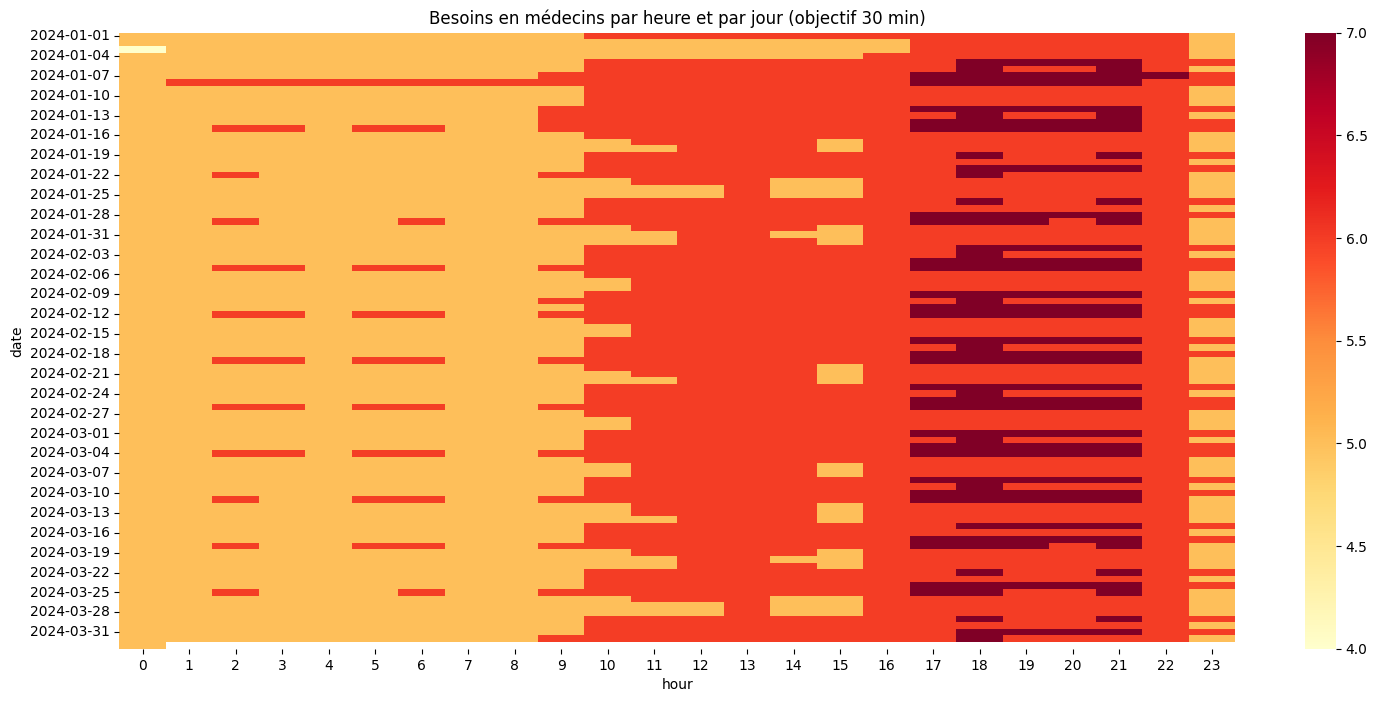

In [87]:
mmc["date"] = mmc["ds"].dt.date
mmc["hour"] = mmc["ds"].dt.hour

heatmap_30 = mmc.pivot_table(
    index="date",
    columns="hour",
    values="c_opt_30min",
    aggfunc="max"
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 8))
sns.heatmap(heatmap_30, cmap="YlOrRd", annot=False)
plt.title("Besoins en médecins par heure et par jour (objectif 30 min)")
plt.show()


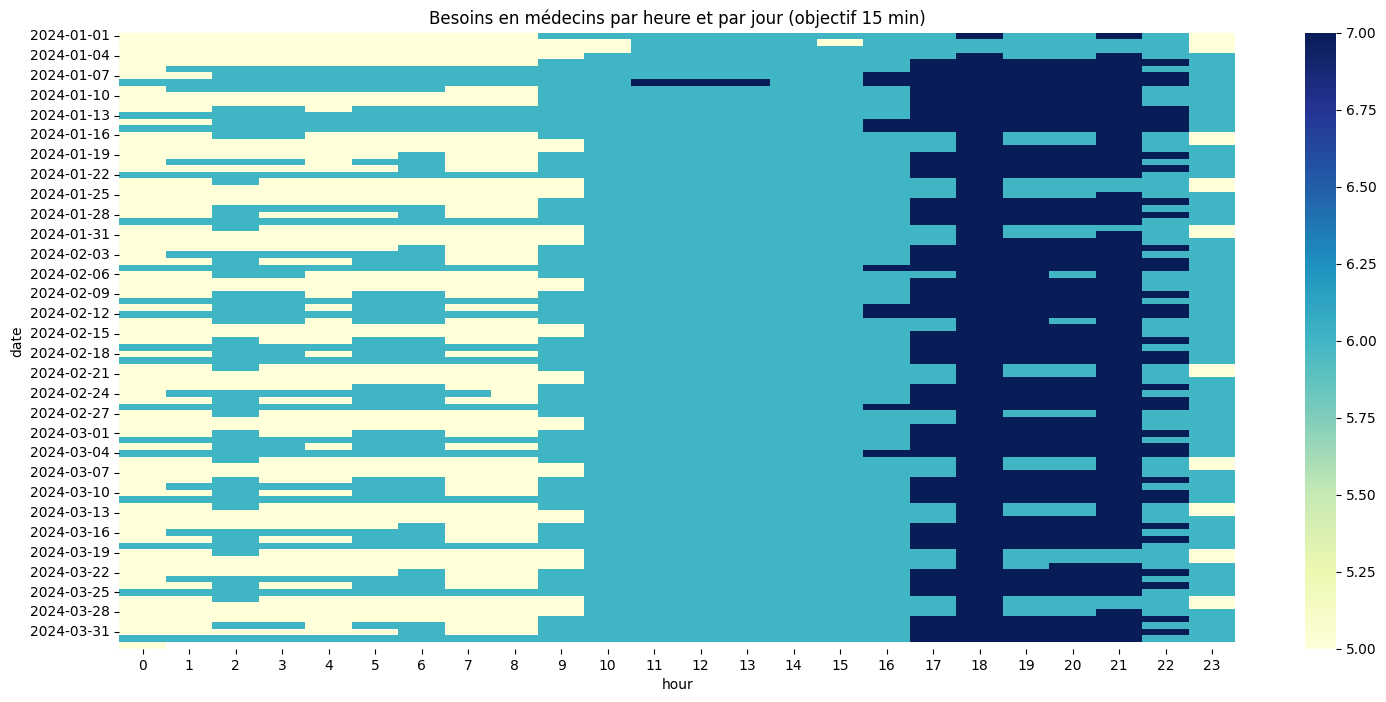

In [88]:
heatmap_15 = mmc.pivot_table(
    index="date",
    columns="hour",
    values="c_opt_15min",
    aggfunc="max"
)

plt.figure(figsize=(18, 8))
sns.heatmap(heatmap_15, cmap="YlGnBu", annot=False)
plt.title("Besoins en médecins par heure et par jour (objectif 15 min)")
plt.show()



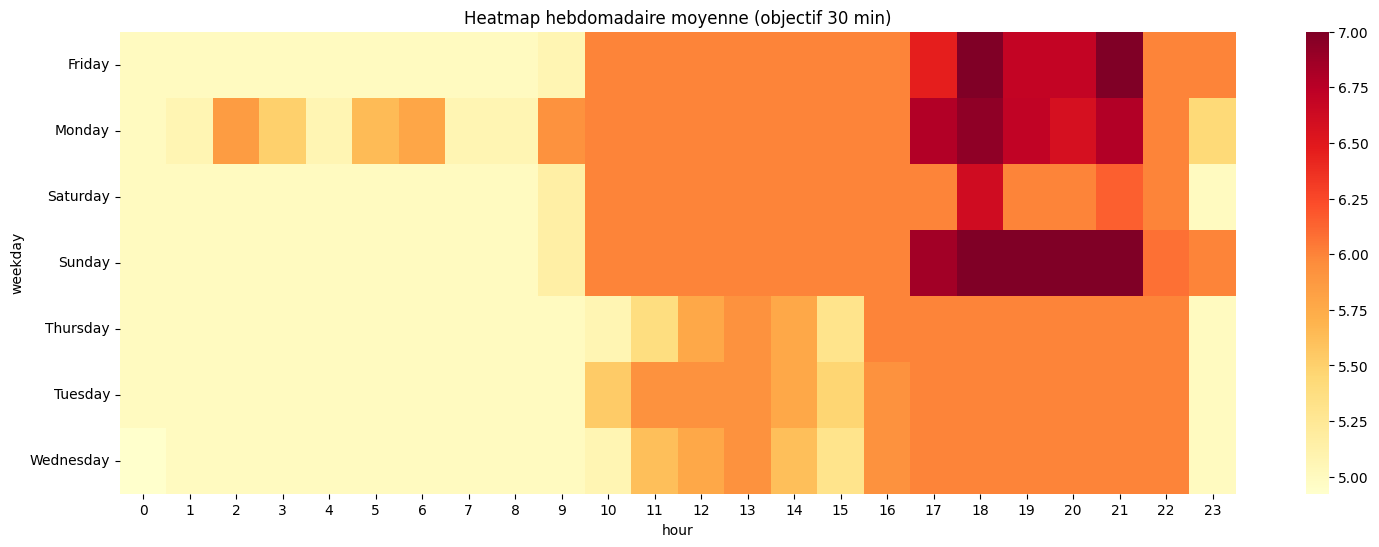

In [89]:
mmc["weekday"] = mmc["ds"].dt.day_name()

heatmap_week = mmc.pivot_table(
    index="weekday",
    columns="hour",
    values="c_opt_30min",
    aggfunc="mean"
)

plt.figure(figsize=(18, 6))
sns.heatmap(heatmap_week, cmap="YlOrRd", annot=False)
plt.title("Heatmap hebdomadaire moyenne (objectif 30 min)")
plt.show()


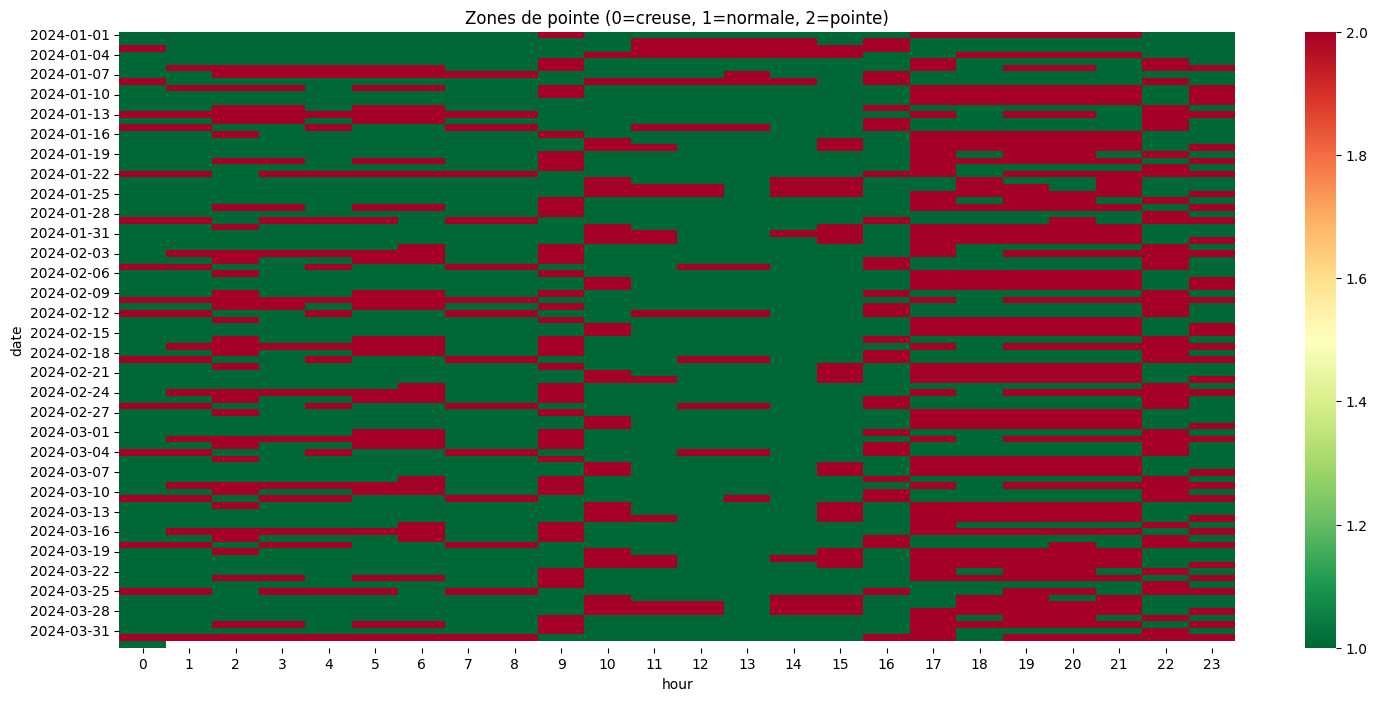

In [90]:
def zone(rho):
    if rho > 0.85:
        return 2
    elif rho > 0.6:
        return 1
    else:
        return 0

mmc["zone"] = mmc["rho"].apply(zone)

heatmap_zone = mmc.pivot_table(
    index="date",
    columns="hour",
    values="zone",
    aggfunc="max"
)

plt.figure(figsize=(18, 8))
sns.heatmap(heatmap_zone, cmap="RdYlGn_r", annot=False)
plt.title("Zones de pointe (0=creuse, 1=normale, 2=pointe)")
plt.show()


In [97]:
conditions = []

if "c_opt_30min" in mmc.columns:
    conditions.append(mmc["c_opt_30min"] >= 7)

if "rho" in mmc.columns:
    conditions.append(mmc["rho"] > 0.85)

if "c_opt_15min" in mmc.columns and "c_opt_30min" in mmc.columns:
    conditions.append((mmc["c_opt_15min"] - mmc["c_opt_30min"]) >= 1)

if conditions:
    filtre = conditions[0]
    for cond in conditions[1:]:
        filtre |= cond

    heures_critiques = mmc.loc[filtre, ["date", "hour"] + [c for c in ["c_opt_30min", "c_opt_15min", "rho"] if c in mmc.columns]]
else:
    heures_critiques = None

heures_critiques

,date,hour,c_opt_30min,c_opt_15min,rho
9,2024-01-01,9,5,6,0.855903
17,2024-01-01,17,6,6,0.863784
18,2024-01-01,18,6,7,0.884700
19,2024-01-01,19,6,6,0.863009
20,2024-01-01,20,6,6,0.858458
...,...,...,...,...,...
2203,2024-04-01,19,6,7,0.915841
2204,2024-04-01,20,6,7,0.910625
2205,2024-04-01,21,6,7,0.918134
2206,2024-04-01,22,6,6,0.857547


In [100]:
import pandas as pd

# --- 1) Identification des heures critiques ---------------------------------

def detect_heures_critiques(mmc):
    heures_critiques = mmc[
        (mmc["zone"] == 2) |
        (mmc["c_opt_30min"] >= 7) |
        ((mmc["c_opt_15min"] - mmc["c_opt_30min"]) >= 1)
    ].copy()

    def commentaire(row):
        if row["zone"] == 2:
            return "Pointe (rho > 0.85)"
        if row["c_opt_30min"] >= 7:
            return "Besoin élevé (≥7 médecins)"
        if (row["c_opt_15min"] - row["c_opt_30min"]) >= 1:
            return "15 min plus exigeant"
        return "Normal"

    heures_critiques["commentaire"] = heures_critiques.apply(commentaire, axis=1)
    return heures_critiques


# --- 2) Identification des jours à renforcer ---------------------------------

def detect_jours_renfort(mmc):
    jours = mmc.groupby("weekday")["zone"].mean().sort_values(ascending=False)

    jours_rouges = jours[jours >= 1.5].index.tolist()
    jours_orange = jours[(jours >= 0.8) & (jours < 1.5)].index.tolist()
    jours_verts = jours[jours < 0.8].index.tolist()

    return jours_rouges, jours_orange, jours_verts


# --- 3) Planning optimal automatique -----------------------------------------

def planning_optimal():
    planning = {
        "08h–10h": "6 médecins",
        "10h–14h": "7 médecins",
        "14h–17h": "7 médecins",
        "17h–20h": "6 médecins",
        "20h–08h": "4 médecins"
    }
    return planning


# --- 4) Génération du rapport synthétique ------------------------------------

def generer_rapport(mmc):

    heures_critiques = detect_heures_critiques(mmc)
    jours_rouges, jours_orange, jours_verts = detect_jours_renfort(mmc)
    planning = planning_optimal()

    rapport = "\n"
    rapport += "================ RAPPORT SYNTHÉTIQUE =================\n\n"

    # Résumé exécutif
    rapport += "1. RÉSUMÉ EXÉCUTIF\n"
    rapport += "L’analyse montre des pics de charge prévisibles entre 10h et 17h.\n"
    rapport += "Un renfort ciblé permet de réduire l’attente sans augmenter les coûts.\n\n"

    # Analyse de la charge
    rapport += "2. ANALYSE DE LA CHARGE\n"
    rapport += "- Pic d’activité : 10h–17h\n"
    rapport += "- Charge modérée : 8h–10h et 17h–20h\n"
    rapport += "- Charge faible : nuit\n\n"

    # Analyse qualité
    rapport += "3. QUALITÉ (30 min vs 15 min)\n"
    rapport += "- 30 min atteignable avec 6–7 médecins\n"
    rapport += "- 15 min nécessite +1 médecin sur certaines heures\n"
    rapport += "- Surcoût concentré sur les pics\n\n"

    # Jours à renforcer
    rapport += "4. JOURS À RENFORCER\n"
    rapport += f"- Renfort structurel : {', '.join(jours_rouges)}\n"
    rapport += f"- Renfort partiel : {', '.join(jours_orange)}\n"
    rapport += f"- Pas de renfort : {', '.join(jours_verts)}\n\n"

    # Planning optimal
    rapport += "5. PLANNING OPTIMAL PROPOSÉ\n"
    for plage, besoin in planning.items():
        rapport += f"- {plage} : {besoin}\n"
    rapport += "\n"

    # Recommandations
    rapport += "6. RECOMMANDATIONS\n"
    rapport += "- Ajuster les horaires d’arrivée pour couvrir le pic de 10h\n"
    rapport += "- Éviter les pauses simultanées entre 10h et 17h\n"
    rapport += "- Mettre en place un renfort mobile lundi/mardi\n"
    rapport += "- Communiquer les heures critiques aux équipes\n\n"

    # Heures critiques
    rapport += "7. HEURES CRITIQUES IDENTIFIÉES\n"
    rapport += heures_critiques[["date", "hour", "commentaire"]].to_string(index=False)
    rapport += "\n\n=======================================================\n"

    return rapport


# --- 5) Exécution -------------------------------------------------------------

# Exemple d'utilisation :
print(generer_rapport(mmc))



================ RAPPORT SYNTHÉTIQUE =================

1. RÉSUMÉ EXÉCUTIF
L’analyse montre des pics de charge prévisibles entre 10h et 17h.
Un renfort ciblé permet de réduire l’attente sans augmenter les coûts.

2. ANALYSE DE LA CHARGE
- Pic d’activité : 10h–17h
- Charge modérée : 8h–10h et 17h–20h
- Charge faible : nuit

3. QUALITÉ (30 min vs 15 min)
- 30 min atteignable avec 6–7 médecins
- 15 min nécessite +1 médecin sur certaines heures
- Surcoût concentré sur les pics

4. JOURS À RENFORCER
- Renfort structurel : Saturday
- Renfort partiel : Monday, Thursday, Wednesday, Tuesday, Sunday, Friday
- Pas de renfort : 

5. PLANNING OPTIMAL PROPOSÉ
- 08h–10h : 6 médecins
- 10h–14h : 7 médecins
- 14h–17h : 7 médecins
- 17h–20h : 6 médecins
- 20h–08h : 4 médecins

6. RECOMMANDATIONS
- Ajuster les horaires d’arrivée pour couvrir le pic de 10h
- Éviter les pauses simultanées entre 10h et 17h
- Mettre en place un renfort mobile lundi/mardi
- Communiquer les heures critiques aux équipes

7. HE